<a href="https://colab.research.google.com/github/pabloecheg/Unsupervised-Learning/blob/main/RETO_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # Conexión con mi unidad en Google Drive

Mounted at /content/drive


In [ ]:
import pandas as pd # manejo de Data Frame en Python
pd.set_option('display.max_columns', 50) # Mostrar mas columnas
import numpy as np
# Librería de gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
# Segmentación
from sklearn.cluster import KMeans # K-means
from sklearn.metrics import silhouette_score # Score selección de clúster
from sklearn.preprocessing import StandardScaler # Estandarización

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/APRENDIZAJE NO SUPERVISADO/BASES DE DATOS/total_incidentes_transito.csv',
                 encoding='latin-1')
df.isna().sum() # Cantidad de datos faltantes

,0
OBJECTID,0
Shape,0
radicado,0
fecha,0
hora,0
dia,0
periodo,0
clase,0
direccion,0
direccion_enc,0


In [ ]:
df = df.dropna() # Eliminar datos faltantes

In [ ]:
df.head()

,OBJECTID,Shape,radicado,fecha,hora,dia,periodo,clase,direccion,direccion_enc,cbml,tipo_geocod,gravedad,barrio,comuna,diseno,dia_nombre,mes,mes_nombre,x_magnamed,y_magnamed,longitud,latitud
0,1,"(4713091.969499999, 2248782.755800003)",1740037,2021-03-03 00:00:00,12:30:00,3,2021,Atropello,TV 39B CR 74 75,TV 039 B 074 000 00000,Sin inf,Malla vial,HERIDO,Laureles,Laureles Estadio,Lote o Predio,MIÉRCOLES,3,MARZO,832175.31,1182578.79,-75.593827,6.245137
1,2,"(4714910.6292, 2244088.547700003)",1756253,2021-07-26 00:00:00,13:00:00,26,2021,Choque,CRA 48 CLL 4SUR,CR 048 S 004 000 00000,1422,Malla vial,SOLO DAÑOS,La Aguacatala,El Poblado,Interseccion,LUNES,7,JULIO,834016.79,1177893.35,-75.577189,6.202779
2,3,"(4715232.050800002, 2247305.6388000026)",1741056,2021-03-02 00:00:00,6:15:00,2,2021,Choque,CR 50 CL 30 28,CR 050 030 000 00000,1012,Malla vial,HERIDO,Perpetuo Socorro,La Candelaria,Tramo de via,MARTES,3,MARZO,834322.61,1181112.07,-75.574427,6.231878
3,4,"(4716026.328000001, 2254477.3071)",1759316,2021-08-24 00:00:00,22:40:00,24,2021,Otro,CR 65 CL 101 101A,CR 065 101 000 00000,509,Malla vial,HERIDO,Girardot,Castilla,Tramo de via,MARTES,8,AGOSTO,835081.85,1188287.79,-75.567569,6.296749
4,5,"(4718366.126200001, 2248621.4102999996)",1754472,2021-07-16 00:00:00,7:40:00,16,2021,Otro,CL 56 CR 26 28,CL 056 026 000 00000,810,Malla vial aproximada: CL 56-25,HERIDO,El Pinal,Villa Hermosa,Lote o Predio,VIERNES,7,JULIO,837450.38,1182443.14,-75.546170,6.243911


In [ ]:
df.shape # Tamaño del Data Frame

(40599, 23)

In [ ]:
df["fecha"].head()

,fecha
0,2021-03-03 00:00:00
1,2021-07-26 00:00:00
2,2021-03-02 00:00:00
3,2021-08-24 00:00:00
4,2021-07-16 00:00:00


In [ ]:
pd.to_datetime(df["fecha"],
               format='%Y-%m-%d %H:%M:%S') # Conversión a fecha

,fecha
0,2021-03-03
1,2021-07-26
2,2021-03-02
3,2021-08-24
4,2021-07-16
5,2021-11-30
6,2021-06-21
7,2021-01-28
8,2021-10-20
9,2021-07-27


In [ ]:
# Creamos una nueva columna
df["Fecha accidente"]= pd.to_datetime(df["fecha"],
               format='%Y-%m-%d %H:%M:%S')

# RETO 2
## PUNTO 1

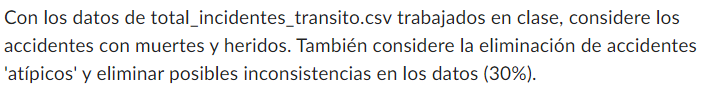

Solamente tener en cuenta los accidentes con herido o muerto

In [ ]:
df2 = df[df["gravedad"].isin(['HERIDO', 'MUERTO'])]
df2["gravedad"].value_counts()

,count
gravedad,
HERIDO,23651
MUERTO,162


Filtrar choques atipicos

In [ ]:
#Miramos cuales son los valores posibles para 'comuna'
df2["comuna"].value_counts()

,count
comuna,
La Candelaria,3542
Castilla,2147
Laureles Estadio,2058
Sin inf,1921
Robledo,1666
Aranjuez,1601
,1509
Guayabal,1304
El Poblado,1095


In [ ]:
# Podemos tener en cuenta solamente las comunas de Medellín y excluír los corregimientos
comunas_excluir = ['SN','Corregimiento De Altavista', 'Corregimiento De Santa Elena',
                   'Corregimiento de San Sebastián de Palmitas', 'Corregimiento De San Antonio De Prado',
                   'In', 'Corregimiento De San Cristóbal', 'Corregimiento de Altavista', 'Sin Inf',
                   'Corregimiento de Santa Elena', 'Corregimiento de San Antonio de Prado',
                   'Corregimiento de San Cristóbal', ' ', 'Sin inf']

df2 = df2[~df2['comuna'].isin(comunas_excluir)]
df2['comuna'].value_counts()

,count
comuna,
La Candelaria,3542
Castilla,2147
Laureles Estadio,2058
Robledo,1666
Aranjuez,1601
Guayabal,1304
El Poblado,1095
Belén,1057
Manrique,996


Filtrar los accidentes atípicos faltantes que están en una longitud menor a -75.65

In [ ]:
filtro_atipico = (df2["longitud"]<-75.65)
df2 = df2[~filtro_atipico]

In [ ]:
#Comprobar que solamente hayan accidentes en el area urbana
fig = px.scatter_mapbox(df2, lat="latitud", lon="longitud", color="comuna")
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

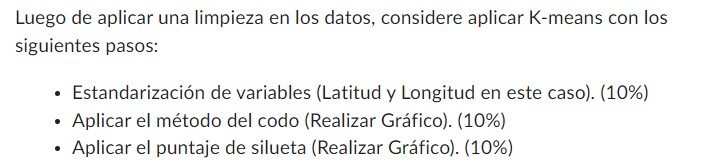

## PUNTO 2

####Estandarización de Latitud y Longitud

In [ ]:
df_var= df2[["longitud","latitud"]] # Seleccionamos las columnas
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_var)
scaled_features # Transforma a numpy, una matriz

array([[-1.12693432, -0.41537182],
       [-0.01748493, -0.91192895],
       [ 0.37475893,  1.51753775],
       ...,
       [ 1.52631918,  0.4205221 ],
       [ 0.6661161 , -0.5284545 ],
       [ 0.92149427,  0.64578004]])

####Metodo del codo

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will 

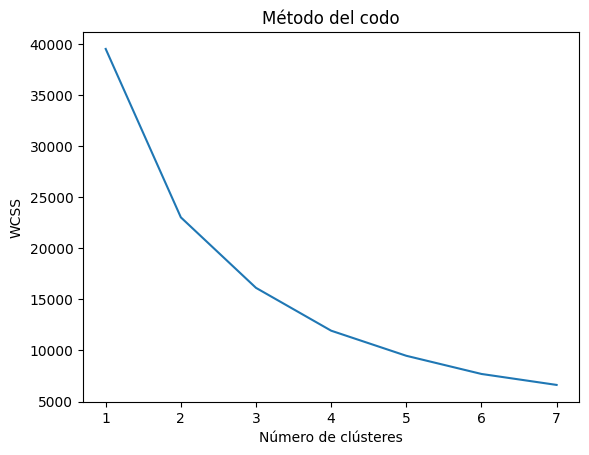

In [ ]:
wcss = [] # valores de WCSS
lista_num_cluster = range(1, 8) # Número de clústeres
# Por cada número de clústeres
for i in lista_num_cluster:
    kmeans = KMeans(n_clusters=i, random_state=123) # Definir el modelo
    kmeans.fit(scaled_features) # entrenar el modelo
    value_wcss= kmeans.inertia_ # extraer el WCSS del modelo
    wcss.append(value_wcss) # Añadir a la lista
# Gráficar resultados
plt.plot(lista_num_cluster, wcss)
plt.title('Método del codo')
plt.xlabel('Número de clústeres')
plt.ylabel('WCSS')
plt.show()

Según el metodo del codo pareciera que nos indica entre dos y tres clústeres

####Puntuación de Silueta

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will 

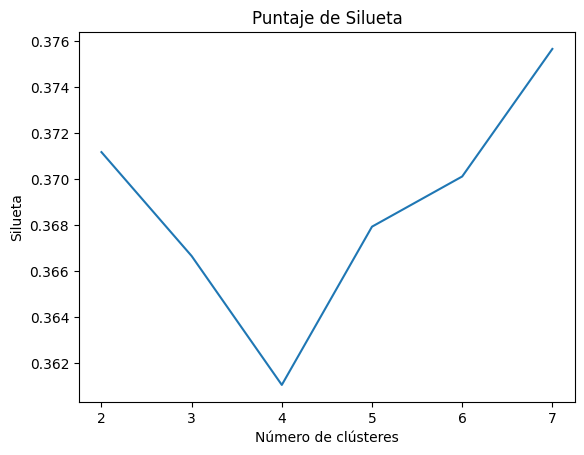

In [ ]:
silueta = [] # valores de puntuación de silueta
lista_num_cluster = range(2, 8) # Número de clústeres
# Por cada número de clústeres
for i in lista_num_cluster:
    kmeans = KMeans(n_clusters=i, random_state=123) # Definir el modelo
    kmeans.fit(scaled_features) # entrenar el modelo
    score_slueta= silhouette_score(scaled_features,  kmeans.labels_)  # Calcular el score
    silueta.append(score_slueta) # Añadir a la lista
# Gráficar resultados
plt.plot(lista_num_cluster, silueta)
plt.title('Puntaje de Silueta')
plt.xlabel('Número de clústeres')
plt.ylabel('Silueta')
plt.show()

Según el puntaje de silueta, su interpretación varía. Pero podríamos decir que indica 2, 5, 6 o 7 Clústeres.

In [ ]:
kmeans = KMeans(n_clusters=7,  random_state=123) # Definir el algoritmo
kmeans.fit(scaled_features)  # Entrenar el modelo
df2["cluster"] = kmeans.labels_ # Obtener las etiquetas
df2["cluster"] = df2["cluster"].astype(str) # Convertir a categoria

fig = px.scatter_mapbox(df2, lat="latitud", lon="longitud", color="cluster")

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



Juntando las conclusiones de ambos gráficos (Silueta y Codo), podríamos decir que estamos entre 3, 5 y 7 clústeres.

Intentando con los tres valores, me parece que la segmentación es acertada en cualquier número de clústeres. Pero teniendo en cuenta el caso de las ambulancias, podríamos decir que entre mas clústeres tengamos, mejor sería la respuesta de emergencias.

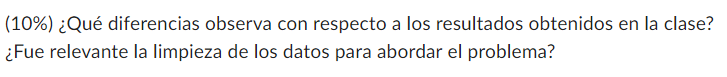

Ya que en clase no habíamos hecho una limpieza, los resultados y la segmentación cambia drásticamente al tener en cuenta solamente los accidentes con heridos o muertos. También la clústerización es mucho mas acertada al momento de tener solamente los accidentes reportados en la zona urbana, deshaciendonos de los accidentes atípicos y accidentes en los corregimientos.

Por esto, creo que la limpieza de datos jugó un rol importante al momento de abordar el problema, ya que le damos un enfoque distinto.